# Desenvolvimento de um pipeline de Machine Learning para predição de casos de dengue

## Esse projeto é sobre predição de casos de dengue registrados diariamente utilizando técnicas de aprendizado por regressão

### - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

### Primeiro vamos realizar uma leitura dos dados e fazer uma análise exploratória com o objetivo de entender mais sobre sua estrutura 

In [15]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sns
import numpy as np

In [3]:
dengue_cases = pd.read_csv("../data/casos_de_dengue_dataset.csv")

### Mostrar os 5 primeiros registros 

In [4]:
dengue_cases.head()

,uf,municipio,precipitacao_total_horario_mm,pressao_atmosferica_ao_nivel_da_estacao_horaria_mb,pressao_atmosferica_max_na_hora_ant_aut_mb,pressao_atmosferica_min_na_hora_ant_aut_mb,temperatura_do_ar_bulbo_seco_horaria_c,temperatura_do_ponto_de_orvalho_c,temperatura_maxima_na_hora_ant_aut_c,temperatura_minima_na_hora_ant_aut_c,...,umidade_rel_min_na_hora_ant_aut,umidade_relativa_do_ar_horaria,vento_direcao_horaria_gr_gr,vento_rajada_maxima_m_s,vento_velocidade_horaria_m_s,casos_dengue,ano,mes,dia,dia_da_semana
0,AC,rio branco,0.242222,992.428472,992.771111,992.087083,25.454028,21.923056,25.978472,24.976806,...,79.205556,81.969444,105.050000,3.214444,0.735556,5.0,2023,1,31,1
1,AC,rio branco,0.250000,992.396806,992.737361,992.058611,25.415417,21.923472,25.942083,24.941111,...,79.375000,82.147222,102.440278,3.193056,0.730139,3.0,2023,2,1,2
2,AC,rio branco,0.250278,992.405556,992.745833,992.066111,25.390972,21.942222,25.918611,24.924444,...,79.602778,82.355556,100.780556,3.130556,0.715139,5.0,2023,2,2,3
3,AC,rio branco,0.269722,992.471250,992.808750,992.130278,25.346250,21.957639,25.870000,24.884167,...,79.879167,82.627778,102.375000,3.072917,0.690139,4.0,2023,2,3,4
4,AC,rio branco,0.268056,992.559861,992.899028,992.218194,25.334583,21.962778,25.853194,24.873611,...,79.965278,82.705556,103.270833,3.016667,0.673472,5.0,2023,2,4,5


### Vamos fazer uma descrição dos dados

In [6]:
dengue_cases.describe()

,precipitacao_total_horario_mm,pressao_atmosferica_ao_nivel_da_estacao_horaria_mb,pressao_atmosferica_max_na_hora_ant_aut_mb,pressao_atmosferica_min_na_hora_ant_aut_mb,temperatura_do_ar_bulbo_seco_horaria_c,temperatura_do_ponto_de_orvalho_c,temperatura_maxima_na_hora_ant_aut_c,temperatura_minima_na_hora_ant_aut_c,temperatura_orvalho_max_na_hora_ant_aut_c,temperatura_orvalho_min_na_hora_ant_aut_c,...,umidade_rel_min_na_hora_ant_aut,umidade_relativa_do_ar_horaria,vento_direcao_horaria_gr_gr,vento_rajada_maxima_m_s,vento_velocidade_horaria_m_s,casos_dengue,ano,mes,dia,dia_da_semana
count,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,...,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000,20327.000000
mean,0.171249,969.199763,969.470736,968.939862,24.007000,18.251533,24.668110,23.407778,18.816926,17.730625,...,70.181876,73.188723,147.431538,4.602952,1.749552,25.162001,2023.956216,6.174743,15.690117,2.867073
std,0.164242,40.560198,40.566240,40.551310,3.175508,4.160004,3.179806,3.183470,4.151094,4.181959,...,10.731616,10.510938,31.117937,1.271396,0.822528,52.704820,0.792163,3.304032,8.773986,1.970945
min,0.000000,865.327778,865.573194,865.082917,12.431746,3.374965,12.946806,11.968591,4.126886,2.623952,...,28.435663,30.666061,50.934259,1.710417,0.131667,1.000000,2023.000000,1.000000,1.000000,0.000000
25%,0.040518,940.603264,940.890107,940.342639,21.880463,15.592083,22.554306,21.270699,16.182408,15.056298,...,63.472222,66.985817,127.739352,3.703895,1.193945,2.000000,2023.000000,3.000000,8.000000,1.000000
50%,0.124167,987.260465,987.557778,986.976086,24.614674,18.841944,25.286667,23.997059,19.418333,18.287361,...,72.633333,75.546991,146.914553,4.575833,1.664044,6.000000,2024.000000,6.000000,16.000000,3.000000
75%,0.258056,1006.315080,1006.581898,1006.039877,26.406389,21.805417,27.027208,25.849653,22.347222,21.321701,...,78.075000,80.893403,168.384033,5.352986,2.260674,22.000000,2025.000000,9.000000,23.000000,5.000000
max,1.109167,1022.612778,1022.834028,1022.395000,31.885718,25.362477,32.527605,31.355278,25.975417,24.821343,...,93.163889,95.636806,261.197222,10.162579,4.994028,712.000000,2025.000000,12.000000,31.000000,6.000000


### Agora vamos montar um mapa de calor para a cidade de Salvador para avaliar quais variáveis estão mais relacionadas com a quantidade de casos de dengue 

### Selecionamos a cidade de Salvador pois como diferentes municípios do Brasil possuem épocas de chuva diferentes, fica mais fácil focar em apenas uma para a avaliação

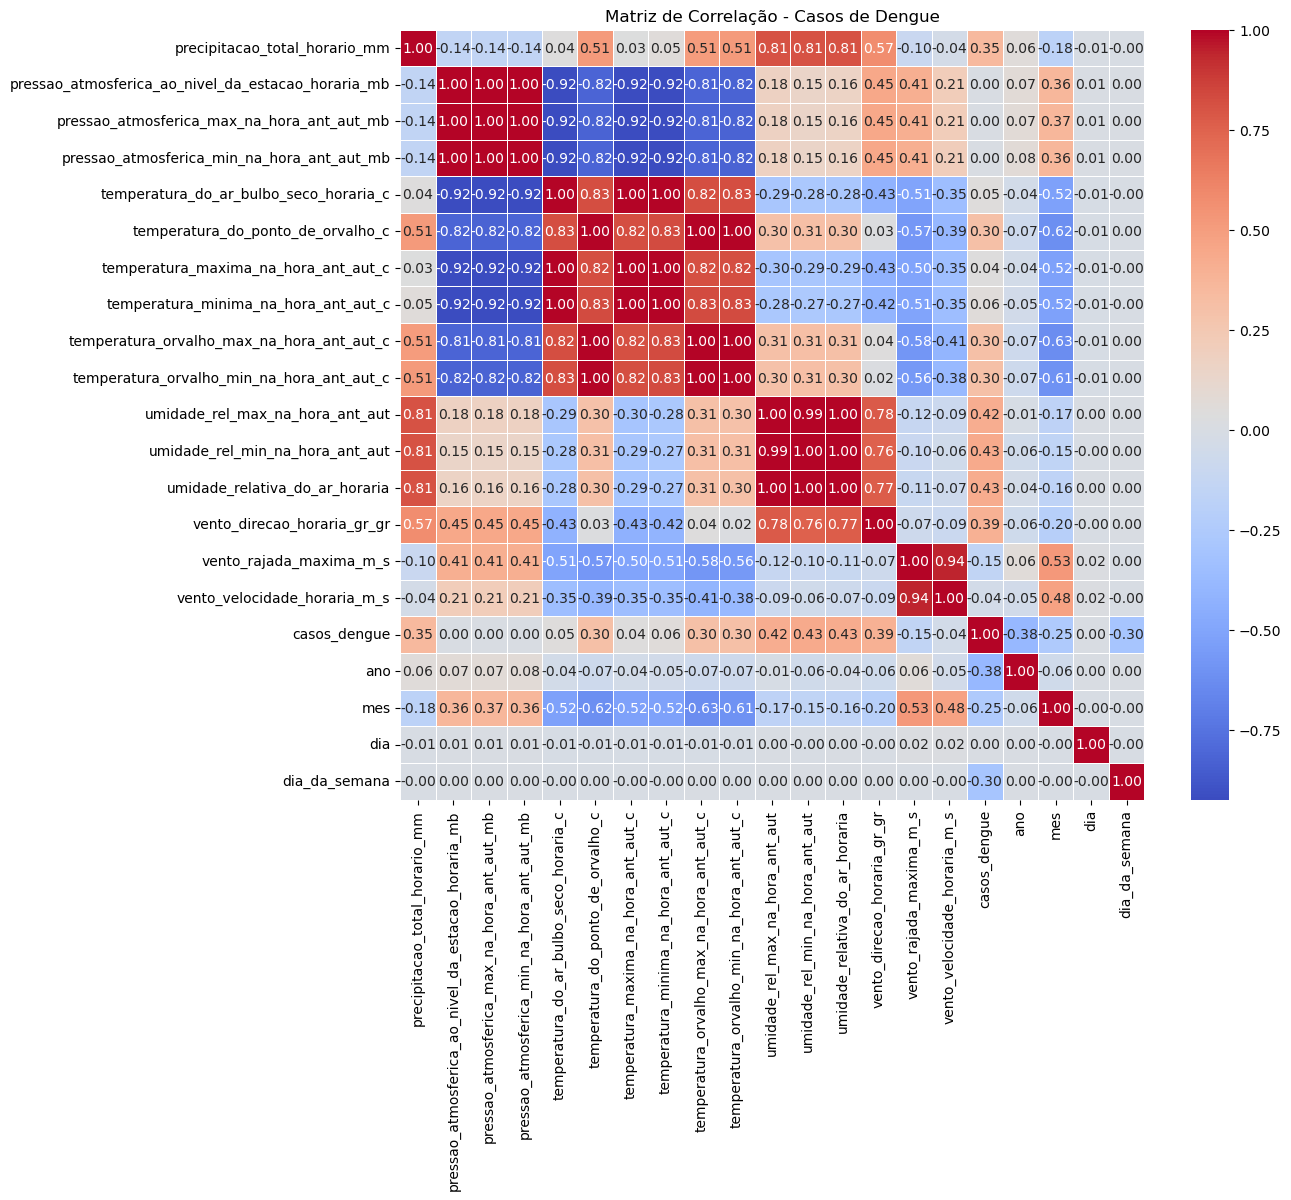

In [26]:
# 1. Primeiro, selecione apenas as colunas numéricas
# Isso remove colunas como 'estado', 'municipio' ou datas em formato string
df_dalvador = dengue_cases[dengue_cases["municipio"] == "salvador"]
df_numerico = df_dalvador.select_dtypes(include=[np.number])

# 2. Calcule a correlação entre as variáveis
# O resultado será uma matriz onde cada célula vai de -1 a 1
corr = df_numerico.corr()

# 3. Agora sim, plote o heatmap
mp.figure(figsize=(12, 10)) # Aumentei um pouco para caber as 21 colunas

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

mp.title('Matriz de Correlação - Casos de Dengue')
mp.show()

### Como pudemos observar, as variáveis que mais se relacionam com os casos de dengue são a preicipitação, umidade e o vento (sugerindo que em dias de chuva com ventania são mais propensos para o contágio da doença)

### Vamos montar um gráfico de linha para os casos e dengue e para a umidade com o passar dos meses para cada ano do dataset e ver como eles estão relacionados (especificamente para a cidade do Salvador)

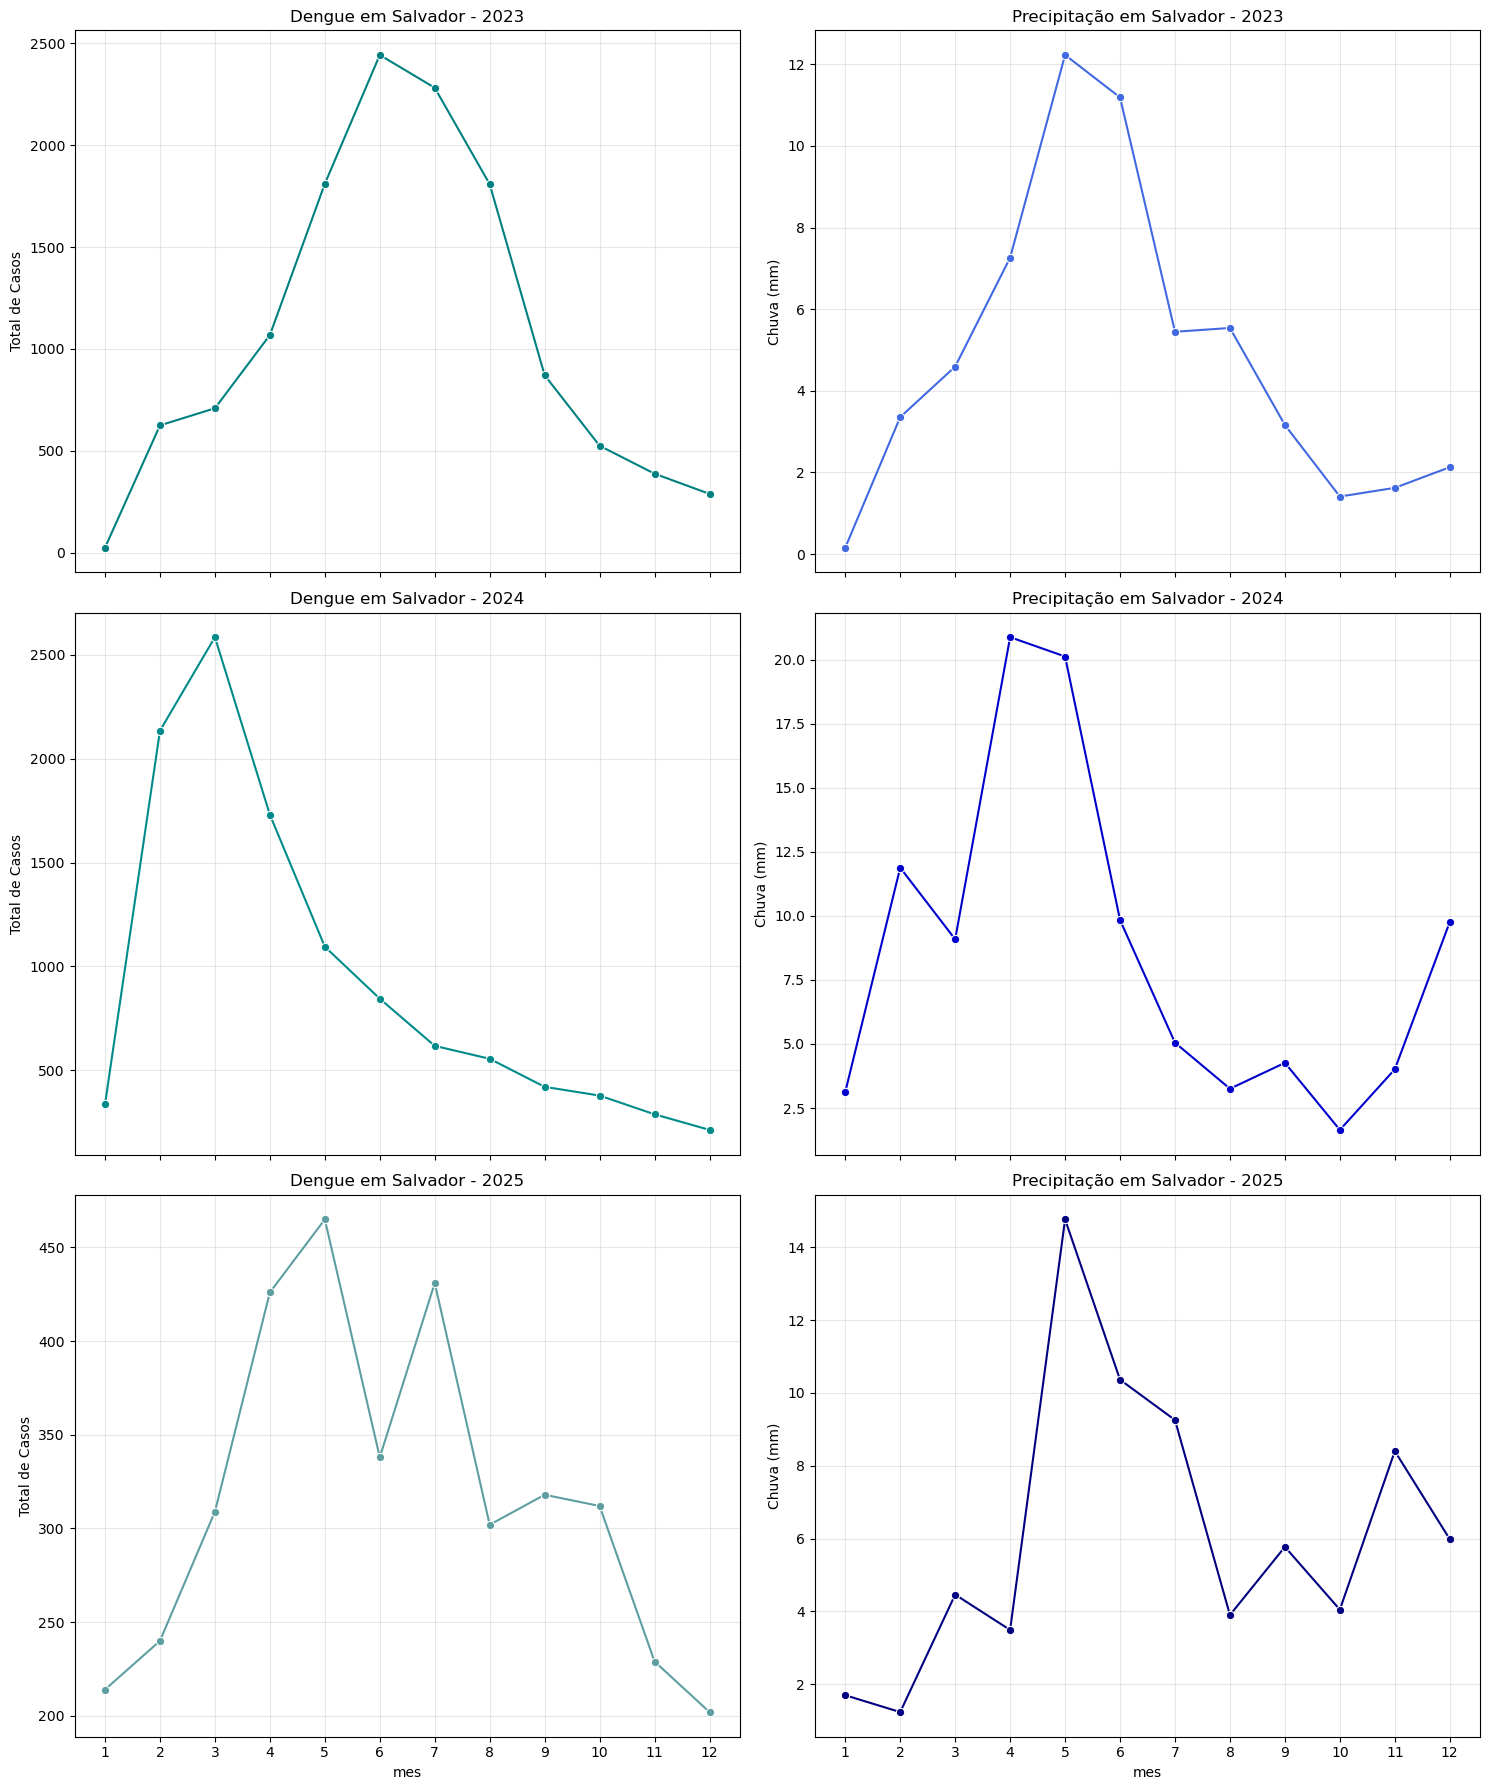

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos dados (Salvador e anos específicos)
anos = [2023, 2024, 2025]
df_salvador = dengue_cases[(dengue_cases['municipio'] == 'salvador') & 
                           (dengue_cases['ano'].isin(anos))]

# Agrupando para garantir os valores somados por mês e ano
df_plot = df_salvador.groupby(['ano', 'mes'])[['casos_dengue', 'precipitacao_total_horario_mm']].sum().reset_index()

# 2. Criar a grade: 3 linhas (anos) e 2 colunas (Dengue vs Chuva)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 18), sharex=True)

# Cores para identificar os anos
cores_dengue = {2023: 'teal', 2024: 'darkcyan', 2025: 'cadetblue'}
cores_chuva = {2023: 'royalblue', 2024: 'mediumblue', 2025: 'navy'}

for i, ano in enumerate(anos):
    # Filtrar dados do ano específico da linha
    dados_ano = df_plot[df_plot['ano'] == ano]
    
    # --- Coluna 1: Casos de Dengue ---
    sns.lineplot(ax=axes[i, 0], data=dados_ano, x='mes', y='casos_dengue', 
                 marker='o', color=cores_dengue[ano])
    axes[i, 0].set_title(f'Dengue em Salvador - {ano}')
    axes[i, 0].set_ylabel('Total de Casos')
    axes[i, 0].grid(True, alpha=0.3)
    
    # --- Coluna 2: Precipitação ---
    sns.lineplot(ax=axes[i, 1], data=dados_ano, x='mes', y='precipitacao_total_horario_mm', 
                 marker='o', color=cores_chuva[ano])
    axes[i, 1].set_title(f'Precipitação em Salvador - {ano}')
    axes[i, 1].set_ylabel('Chuva (mm)')
    axes[i, 1].grid(True, alpha=0.3)

# Ajustes finais
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## Agora vamos tratar os dados para aplicar o modelo linear ridge regression para predizer os casos de dengue 

### Primeiro vamos fazer o processo de encoder nas variáveis de uf e municipio 

In [40]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Definindo quais colunas serão transformadas e quais serão mantidas
colunas_categoricas = ['uf', 'municipio']
# Adicione aqui as outras colunas que você quer manter no modelo (clima, ano, etc.)
# Se quiser manter todas as outras, o 'remainder="passthrough"' cuida disso.

# 2. Configurando o OneHotEncoder
# sparse_output=False garante que o resultado seja uma matriz densa fácil de converter em DataFrame
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 3. Criando o transformador de colunas
ct = ColumnTransformer(transformers=[
    ('onehot', encoder, colunas_categoricas)
], remainder='passthrough')

# 4. Aplicando a transformação
# O fit_transform retorna um array NumPy
dados_transformados = ct.fit_transform(dengue_cases)

# 5. Criando o novo dataset (DataFrame) com os nomes das colunas corretos
# get_feature_names_out recupera os nomes como 'onehot__municipio_manaus', etc.
nomes_colunas = ct.get_feature_names_out()
dengue_cases_transformed = pd.DataFrame(dados_transformados, columns=nomes_colunas)

# Exibindo o resultado
print(f"Total de colunas após encoding: {dengue_cases_transformed.shape[1]}")

Total de colunas após encoding: 63
   onehot__uf_AC  onehot__uf_AM  onehot__uf_BA  onehot__uf_ES  onehot__uf_GO  \
0            1.0            0.0            0.0            0.0            0.0   
1            1.0            0.0            0.0            0.0            0.0   
2            1.0            0.0            0.0            0.0            0.0   
3            1.0            0.0            0.0            0.0            0.0   
4            1.0            0.0            0.0            0.0            0.0   

   onehot__uf_MG  onehot__uf_MS  onehot__uf_PA  onehot__uf_PI  onehot__uf_PR  \
0            0.0            0.0            0.0            0.0            0.0   
1            0.0            0.0            0.0            0.0            0.0   
2            0.0            0.0            0.0            0.0            0.0   
3            0.0            0.0            0.0            0.0            0.0   
4            0.0            0.0            0.0            0.0            0.0   

   

In [70]:
# 1. Removendo 'onehot__' e 'remainder__' dos nomes das colunas
dengue_cases_transformed.columns = (
    dengue_cases_transformed.columns
    .str.replace('onehot__', '', regex=False)
    .str.replace('remainder__', '', regex=False)
)


### Em seguida vamos fazer alterações nas variáveis de mes, dia e dia_da_semana, definindo elas em função de sen e cos

In [57]:
import numpy as np

# Função para transformar colunas em Seno e Cosseno
def encode_cyclical(df, col, max_val):
    # O df[col] aqui acessa os valores exatos da sua lista
    df[col + '_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[col + '_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df.drop(columns=[col])

# 1. Aplicando para Mês (1 a 12)
dengue_cases_transformed = encode_cyclical(dengue_cases_transformed, 'mes', 12)

# 2. Aplicando para Dia (1 a 31)
dengue_cases_transformed = encode_cyclical(dengue_cases_transformed, 'dia', 31)

# 3. Aplicando para Dia da Semana (0 a 6 ou 1 a 7)
# Use 7 como divisor para manter a proporção da semana
dengue_cases_transformed = encode_cyclical(dengue_cases_transformed, 'dia_da_semana', 7)

# Visualizando as novas colunas
print(dengue_cases_transformed[['mes_sin', 'mes_cos', 'dia_da_semana_sin']].head())

    mes_sin   mes_cos  dia_da_semana_sin
0  0.500000  0.866025           0.781831
1  0.866025  0.500000           0.974928
2  0.866025  0.500000           0.433884
3  0.866025  0.500000          -0.433884
4  0.866025  0.500000          -0.974928


### Por fim vamos separas os dados de treinamento e os dados de teste e em seguida aplicar a normalização

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Definir as colunas que devem ser normalizadas (conforme sua lista)
colunas_para_escalar = [
    'precipitacao_total_horario_mm',
    'pressao_atmosferica_ao_nivel_da_estacao_horaria_mb',
    'pressao_atmosferica_max_na_hora_ant_aut_mb',
    'pressao_atmosferica_min_na_hora_ant_aut_mb',
    'temperatura_do_ar_bulbo_seco_horaria_c',
    'temperatura_do_ponto_de_orvalho_c',
    'temperatura_maxima_na_hora_ant_aut_c',
    'temperatura_minima_na_hora_ant_aut_c',
    'temperatura_orvalho_max_na_hora_ant_aut_c',
    'temperatura_orvalho_min_na_hora_ant_aut_c',
    'umidade_rel_max_na_hora_ant_aut', 
    'umidade_rel_min_na_hora_ant_aut',
    'umidade_relativa_do_ar_horaria', 
    'vento_direcao_horaria_gr_gr',
    'vento_rajada_maxima_m_s', 
    'vento_velocidade_horaria_m_s',
    'ano', 
    'mes_sin', 'mes_cos', 
    'dia_sin', 'dia_cos',
    'dia_da_semana_sin', 'dia_da_semana_cos'
]

# 2. Separar variáveis preditoras (X) e o alvo (y)
X = dengue_cases_transformed.drop(columns=['casos_dengue'])
y = dengue_cases_transformed['casos_dengue']

# 3. Dividir em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Criar e aplicar o Scaler
scaler = StandardScaler()

# IMPORTANTE: 
# .fit_transform() apenas no treino (aprende média/desvio e transforma)
# .transform() no teste (usa a média/desvio aprendida no treino)
X_train[colunas_para_escalar] = scaler.fit_transform(X_train[colunas_para_escalar])
X_test[colunas_para_escalar] = scaler.transform(X_test[colunas_para_escalar])

# 5. Verificação rápida
print("Média da primeira coluna escalada (deve ser próxima de 0):", X_train[colunas_para_escalar[0]].mean())
print("Desvio padrão da primeira coluna escalada (deve ser 1):", X_train[colunas_para_escalar[0]].std())

Média da primeira coluna escalada (deve ser próxima de 0): -2.3158947786289472e-17
Desvio padrão da primeira coluna escalada (deve ser 1): 1.0000307498347212


### Agora os dados já estão prontos para serem aplicados no modelo

In [71]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Definir os valores de alpha para testar (de 0.1 até 1000)
# Alpha alto = mais regularização (evita decorar os dados)
# Alpha baixo = mais próximo da regressão linear comum
alphas = [0.1,1.0,10.0]

# 2. Criar e treinar o modelo
# scoring='neg_mean_absolute_error' faz ele otimizar para errar o menos possível em números de casos
modelo_ridge = RidgeCV(alphas=alphas, scoring='neg_mean_absolute_error')
modelo_ridge.fit(X_train, y_train)

# 3. Fazer previsões no conjunto de teste
y_pred = modelo_ridge.predict(X_test)

# 4. Avaliar os resultados
print(f"Melhor Alpha escolhido: {modelo_ridge.alpha_}")

Melhor Alpha escolhido: 1.0


In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Cálculos das métricas básicas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 2. Cálculo do CV RMSE médio (Validação Cruzada)
# Usamos o X_train e y_train para validar a performance média do modelo
# scoring='neg_mean_squared_error' retorna valores negativos, por isso o sinal de menos
cv_mses = cross_val_score(modelo_ridge, X_train, y_train, 
                          scoring='neg_mean_squared_error', cv=5)
cv_rmse_medio = np.mean(np.sqrt(-cv_mses))

# 3. Printando os resultados de forma organizada
print("-" * 30)
print("MÉTRICAS DE PERFORMANCE")p
print("-" * 30)
print(f"MAE:            {mae:.4f}")
print(f"MSE:            {mse:.4f}")
print(f"RMSE:           {rmse:.4f}")
print(f"R²:             {r2:.4f}")
print(f"CV RMSE Médio:  {cv_rmse_medio:.4f}")
print("-" * 30)

------------------------------
MÉTRICAS DE PERFORMANCE
------------------------------
MAE:            25.9123
MSE:            1878.2282
RMSE:           43.3385
R²:             0.3094
CV RMSE Médio:  43.6980
------------------------------


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

# Vamos realizar o mesmo procedimento mas dessa vez aplicando o método de redução de dimensionalidade PCA

In [73]:
from sklearn.decomposition import PCA

# 1. Definir o PCA
# 'n_components=0.95' significa que o PCA escolherá o número de componentes 
# necessário para manter 95% da informação (variância) dos dados originais.
pca = PCA(n_components=0.95)

# 2. Aplicar o PCA apenas nas colunas que foram normalizadas (clima e tempo)
X_train_pca_cont = pca.fit_transform(X_train[colunas_para_escalar])
X_test_pca_cont = pca.transform(X_test[colunas_para_escalar])

# 3. Criar novos DataFrames com os componentes principais
colunas_pca = [f'PC{i+1}' for i in range(X_train_pca_cont.shape[1])]
X_train_pca_df = pd.DataFrame(X_train_pca_cont, columns=colunas_pca, index=X_train.index)
X_test_pca_df = pd.DataFrame(X_test_pca_cont, columns=colunas_pca, index=X_test.index)

# 4. Juntar os componentes principais com as colunas binárias (UF e Município) que ficaram de fora
X_train_final = pd.concat([X_train_pca_df, X_train.drop(columns=colunas_para_escalar)], axis=1)
X_test_final = pd.concat([X_test_pca_df, X_test.drop(columns=colunas_para_escalar)], axis=1)

print(f"Número de componentes criados: {len(colunas_pca)}")

Número de componentes criados: 11


In [74]:
# 5. Treinar o modelo com os dados do PCA
modelo_pca = RidgeCV(alphas=[0.1, 1.0, 10.0])
modelo_pca.fit(X_train_final, y_train)

# 6. Previsões e Métricas
y_pred_pca = modelo_pca.predict(X_test_final)

mse_pca = mean_squared_error(y_test, y_pred_pca)
print("-" * 30)
print(f"Métricas com PCA ({len(colunas_pca)} componentes):")
print(f"R²:    {r2_score(y_test, y_pred_pca):.4f}")
print(f"MAE:   {mean_absolute_error(y_test, y_pred_pca):.4f}")
print(f"RMSE:  {np.sqrt(mse_pca):.4f}")

------------------------------
Métricas com PCA (11 componentes):
R²:    0.2947
MAE:   25.9812
RMSE:  43.7965


# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

## Para finalizar nossa análise vamos aplicar a base de dados sem as colunas de uf, municipio e os dados de tempo 

In [75]:
# Lista de colunas climáticas (baseada no seu print anterior)
colunas_clima = [
    'precipitacao_total_horario_mm',
    'pressao_atmosferica_ao_nivel_da_estacao_horaria_mb',
    'pressao_atmosferica_max_na_hora_ant_aut_mb',
    'pressao_atmosferica_min_na_hora_ant_aut_mb',
    'temperatura_do_ar_bulbo_seco_horaria_c',
    'temperatura_do_ponto_de_orvalho_c',
    'temperatura_maxima_na_hora_ant_aut_c',
    'temperatura_minima_na_hora_ant_aut_c',
    'temperatura_orvalho_max_na_hora_ant_aut_c',
    'temperatura_orvalho_min_na_hora_ant_aut_c',
    'umidade_rel_max_na_hora_ant_aut', 
    'umidade_rel_min_na_hora_ant_aut',
    'umidade_relativa_do_ar_horaria', 
    'vento_direcao_horaria_gr_gr',
    'vento_rajada_maxima_m_s', 
    'vento_velocidade_horaria_m_s'
]

# Criando o dataset apenas com clima
df_clima = dengue_cases[colunas_clima + ['casos_dengue']].copy()

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
import numpy as np

# 1. Separando X e y
X_clima = df_clima.drop(columns=['casos_dengue'])
y_clima = df_clima['casos_dengue']

# 2. Split Treino/Teste
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clima, y_clima, test_size=0.2, random_state=42
)

# 3. Normalização (Obrigatória para Ridge)
scaler_c = StandardScaler()
X_train_scaled = scaler_c.fit_transform(X_train_c)
X_test_scaled = scaler_c.transform(X_test_c)

In [77]:
# 4. Treinando o modelo
modelo_clima = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 1000.0])
modelo_clima.fit(X_train_scaled, y_train_c)

# 5. Previsão e Métricas
y_pred_c = modelo_clima.predict(X_test_scaled)

# Cálculo das métricas
mae_c = mean_absolute_error(y_test_c, y_pred_c)
rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_c))
r2_c = r2_score(y_test_c, y_pred_c)

print("-" * 30)
print("ANÁLISE: APENAS CLIMA")
print("-" * 30)
print(f"R²:    {r2_c:.4f}")
print(f"MAE:   {mae_c:.4f} casos")
print(f"RMSE:  {rmse_c:.4f}")
print(f"Melhor Alpha: {modelo_clima.alpha_}")

------------------------------
ANÁLISE: APENAS CLIMA
------------------------------
R²:    0.0719
MAE:   27.8977 casos
RMSE:  50.2410
Melhor Alpha: 0.1
